# Predição de Risco de Sinistro em Equipamentos Agrícolas

## Challenge SOMPO

### Objetivo do Projeto

Desenvolver uma solução baseada em Machine Learning capaz de prever o risco de ocorrência de sinistros em equipamentos agrícolas.

A proposta busca auxiliar seguradoras na identificação preventiva de riscos relacionados a:

- colisões
- operação próxima de água
- transporte
- roubo/furto

A utilização de inteligência artificial permite transformar dados em decisões mais inteligentes, eficientes e preventivas.

# Metodologia CRISP-DM

O projeto foi desenvolvido utilizando a metodologia CRISP-DM, amplamente aplicada em projetos de Data Science.

## 1. Entendimento do Negócio
Compreender fatores que aumentam o risco de sinistro em equipamentos agrícolas.

## 2. Entendimento dos Dados
Analisar variáveis operacionais, ambientais e históricas.

## 3. Preparação dos Dados
Realizar limpeza, tratamento e transformação das variáveis.

## 4. Modelagem
Preparar os dados para utilização em modelos de Machine Learning.

## 5. Avaliação
Analisar padrões e comportamento dos dados.

## 6. Implantação
Possível integração futura com dashboards, APIs e sistemas corporativos.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

plt.rcParams["axes.titlesize"] = 14

# Criação do Dataset

Como não possuímos acesso aos dados reais da seguradora, foi criado um dataset simulado baseado em cenários operacionais do agronegócio.

As variáveis representam fatores ambientais, operacionais e históricos que podem influenciar o risco de sinistro.

In [3]:
np.random.seed(42)

n = 2000

data = pd.DataFrame({

    # Operacionais
    "tipo_operacao": np.random.choice(
        ["campo", "transporte"],
        n
    ),

    "velocidade_media": np.random.randint(
        10,
        70,
        n
    ),

    "tempo_uso_anos": np.random.randint(
        1,
        15,
        n
    ),

    "distancia_percorrida_km": np.random.randint(
        50,
        1000,
        n
    ),

    # Ambientais
    "chuva": np.random.choice(
        ["sim", "nao"],
        n,
        p=[0.4, 0.6]
    ),

    "proximidade_agua": np.random.choice(
        ["sim", "nao"],
        n,
        p=[0.3, 0.7]
    ),

    "temperatura": np.random.randint(
        15,
        40,
        n
    ),

    # Segurança
    "operacao_noturna": np.random.choice(
        ["sim", "nao"],
        n,
        p=[0.35, 0.65]
    ),

    "regiao_risco": np.random.choice(
        ["alta", "media", "baixa"],
        n,
        p=[0.3, 0.4, 0.3]
    ),

    # Histórico
    "historico_sinistro": np.random.choice(
        ["sim", "nao"],
        n,
        p=[0.25, 0.75]
    ),

    # Manutenção
    "manutencao_atrasada": np.random.choice(
        ["sim", "nao"],
        n,
        p=[0.3, 0.7]
    )

})

# Criação da Variável Alvo

A variável "sinistro" representa a ocorrência de incidentes envolvendo equipamentos agrícolas.

Sua construção foi baseada em fatores operacionais, ambientais e históricos.

In [4]:
risco = (

    (
        (data["chuva"] == "sim") &
        (data["proximidade_agua"] == "sim")
    )

    |

    (
        data["velocidade_media"] > 55
    )

    |

    (
        (data["historico_sinistro"] == "sim") &
        (data["operacao_noturna"] == "sim")
    )

    |

    (
        (data["manutencao_atrasada"] == "sim") &
        (data["tempo_uso_anos"] > 10)
    )

)

data["sinistro"] = risco.astype(int)

# Adição de Variabilidade

Foi inserido um pequeno nível de aleatoriedade para tornar o dataset mais próximo de cenários reais.

In [5]:
ruido = np.random.choice(
    [0,1],
    size=n,
    p=[0.95,0.05]
)

data.loc[
    ruido == 1,
    "sinistro"
] = 1 - data.loc[
    ruido == 1,
    "sinistro"
]

# Dicionário de Dados

A tabela abaixo apresenta a descrição das variáveis utilizadas no projeto.

In [6]:
dicionario = pd.DataFrame({

    "Variável": data.columns,

    "Descrição": [

        "Tipo de operação",

        "Velocidade média",

        "Tempo de uso do equipamento",

        "Distância percorrida",

        "Condição climática",

        "Operação próxima à água",

        "Temperatura ambiente",

        "Operação noturna",

        "Classificação da região",

        "Histórico de sinistro",

        "Manutenção atrasada",

        "Ocorrência de sinistro"

    ]
})

dicionario

,Variável,Descrição
0,tipo_operacao,Tipo de operação
1,velocidade_media,Velocidade média
2,tempo_uso_anos,Tempo de uso do equipamento
3,distancia_percorrida_km,Distância percorrida
4,chuva,Condição climática
5,proximidade_agua,Operação próxima à água
6,temperatura,Temperatura ambiente
7,operacao_noturna,Operação noturna
8,regiao_risco,Classificação da região
9,historico_sinistro,Histórico de sinistro


# Análise Inicial dos Dados

Nesta etapa analisamos:
- estrutura do dataset
- tipos de variáveis
- estatísticas descritivas
- possíveis inconsistências

In [7]:
data.head()

,tipo_operacao,velocidade_media,tempo_uso_anos,distancia_percorrida_km,chuva,proximidade_agua,temperatura,operacao_noturna,regiao_risco,historico_sinistro,manutencao_atrasada,sinistro
0,campo,56,12,101,sim,sim,38,nao,baixa,nao,nao,1
1,transporte,21,8,905,nao,nao,26,nao,baixa,nao,sim,0
2,campo,25,8,202,nao,sim,30,nao,media,nao,nao,0
3,campo,33,6,798,sim,nao,26,sim,media,nao,nao,0
4,campo,28,12,360,nao,nao,33,nao,baixa,nao,nao,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tipo_operacao            2000 non-null   object
 1   velocidade_media         2000 non-null   int64 
 2   tempo_uso_anos           2000 non-null   int64 
 3   distancia_percorrida_km  2000 non-null   int64 
 4   chuva                    2000 non-null   object
 5   proximidade_agua         2000 non-null   object
 6   temperatura              2000 non-null   int64 
 7   operacao_noturna         2000 non-null   object
 8   regiao_risco             2000 non-null   object
 9   historico_sinistro       2000 non-null   object
 10  manutencao_atrasada      2000 non-null   object
 11  sinistro                 2000 non-null   int64 
dtypes: int64(5), object(7)
memory usage: 187.6+ KB


In [9]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tipo_operacao,2000,2,campo,1016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
velocidade_media,2000.0,NaN,NaN,NaN,39.321,17.255313,10.0,24.0,39.0,54.0,69.0
tempo_uso_anos,2000.0,NaN,NaN,NaN,7.413,4.022751,1.0,4.0,7.0,11.0,14.0
distancia_percorrida_km,2000.0,NaN,NaN,NaN,540.278,278.574533,50.0,295.0,539.0,783.25,999.0
chuva,2000,2,nao,1184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
proximidade_agua,2000,2,nao,1385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperatura,2000.0,NaN,NaN,NaN,27.2335,7.047255,15.0,21.0,27.0,33.0,39.0
operacao_noturna,2000,2,nao,1317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
regiao_risco,2000,3,media,781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
historico_sinistro,2000,2,nao,1485,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Limpeza dos Dados

Foi realizada a verificação de valores ausentes e inconsistências no dataset.

In [10]:
data.isnull().sum()

,0
tipo_operacao,0
velocidade_media,0
tempo_uso_anos,0
distancia_percorrida_km,0
chuva,0
proximidade_agua,0
temperatura,0
operacao_noturna,0
regiao_risco,0
historico_sinistro,0


# Tratamento das Variáveis Categóricas

As variáveis categóricas foram convertidas para formato numérico utilizando Label Encoding.

Esse processo é necessário porque algoritmos de Machine Learning trabalham com representações numéricas dos dados.

In [11]:
le = LabelEncoder()

colunas_categoricas = [

    "tipo_operacao",
    "chuva",
    "proximidade_agua",
    "operacao_noturna",
    "regiao_risco",
    "historico_sinistro",
    "manutencao_atrasada"

]

for col in colunas_categoricas:
    data[col] = le.fit_transform(data[col])

data.head()

,tipo_operacao,velocidade_media,tempo_uso_anos,distancia_percorrida_km,chuva,proximidade_agua,temperatura,operacao_noturna,regiao_risco,historico_sinistro,manutencao_atrasada,sinistro
0,0,56,12,101,1,1,38,0,1,0,0,1
1,1,21,8,905,0,0,26,0,1,0,1,0
2,0,25,8,202,0,1,30,0,2,0,0,0
3,0,33,6,798,1,0,26,1,2,0,0,0
4,0,28,12,360,0,0,33,0,1,0,0,0


# Análise Exploratória de Dados (EDA)

A análise exploratória busca identificar padrões, relações e comportamentos relacionados ao risco de sinistro.

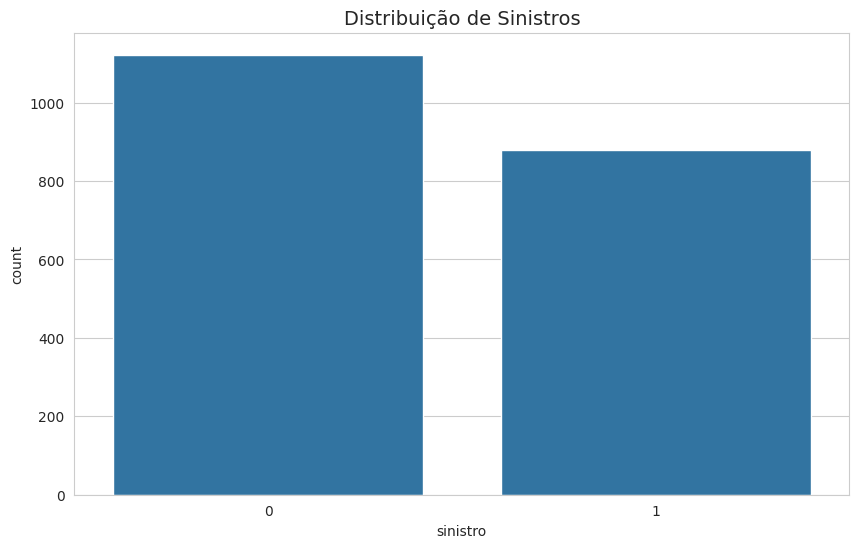

In [12]:
sns.countplot(
    x=data["sinistro"]
)

plt.title("Distribuição de Sinistros")

plt.show()

In [13]:
data["sinistro"].value_counts()

,count
sinistro,
0,1122
1,878


In [14]:
data["sinistro"].value_counts(normalize=True)

,proportion
sinistro,
0,0.561
1,0.439


A distribuição das classes demonstra equilíbrio razoável entre ocorrências e não ocorrências de sinistro, permitindo análises mais confiáveis.

A análise da distribuição das classes permite verificar o balanceamento entre ocorrências e não ocorrências de sinistro, fator importante para futuras etapas de Machine Learning.

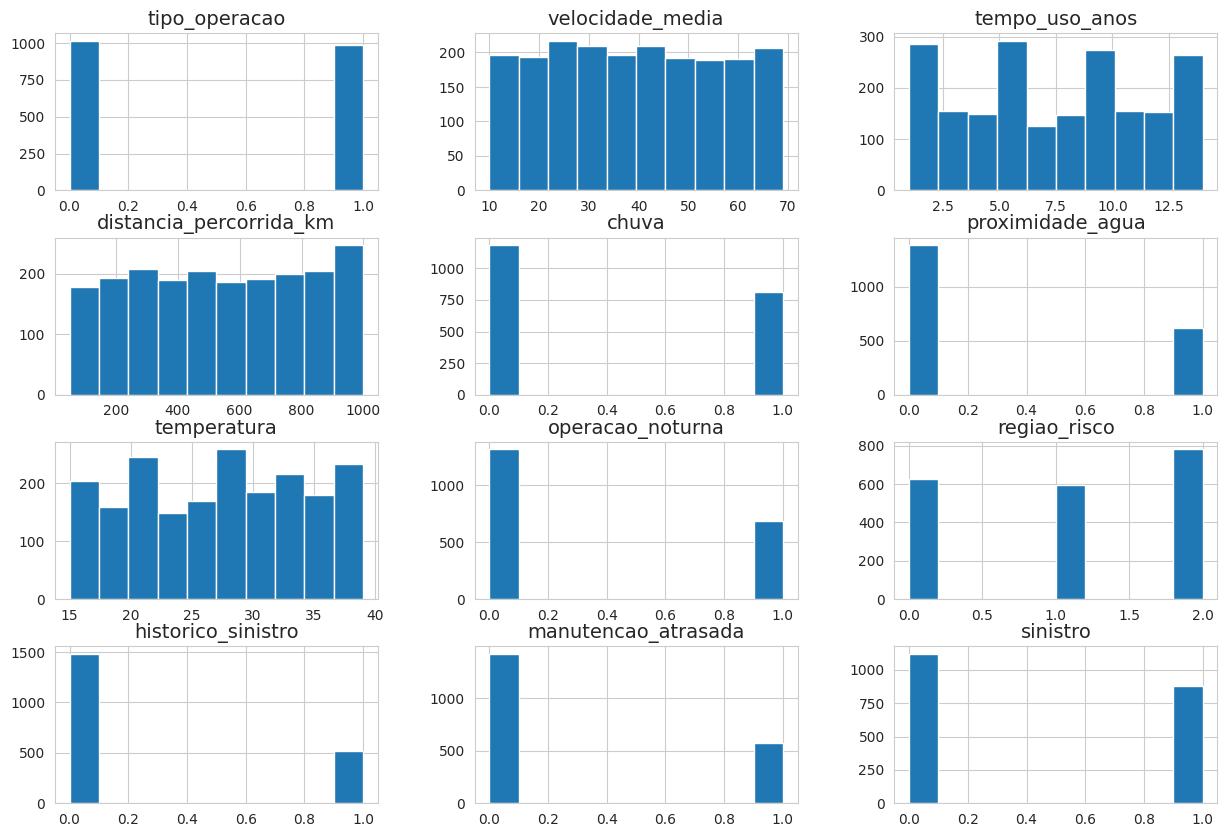

In [15]:
data.hist(
    figsize=(15,10)
)

plt.show()

Os histogramas permitem visualizar a distribuição das variáveis numéricas do dataset.

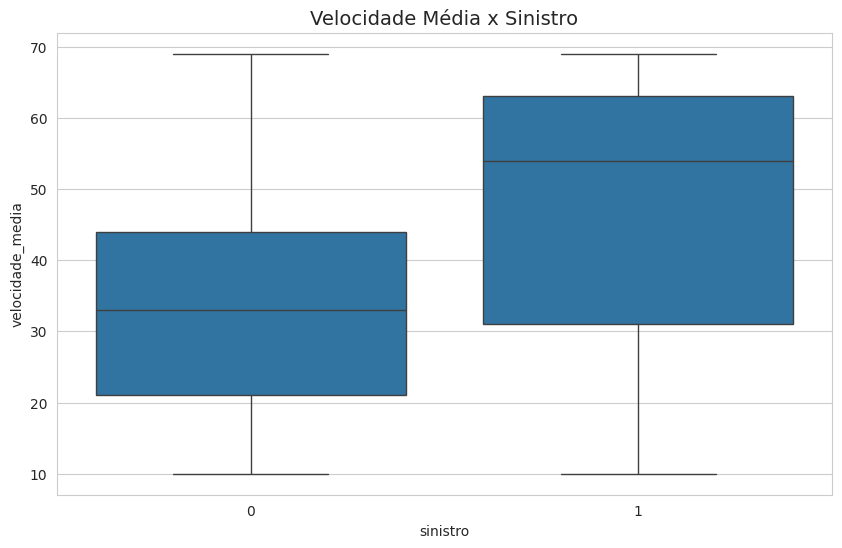

In [16]:
sns.boxplot(
    x="sinistro",
    y="velocidade_media",
    data=data
)

plt.title("Velocidade Média x Sinistro")

plt.show()

Equipamentos envolvidos em sinistros tendem a apresentar velocidades médias mais elevadas.

# Comparação Estatística entre os Grupos

Nesta etapa analisamos médias das variáveis em equipamentos com e sem sinistro.

In [17]:
data.groupby("sinistro")[
    [
        "velocidade_media",
        "tempo_uso_anos",
        "temperatura",
        "distancia_percorrida_km"
    ]
].mean()

,velocidade_media,tempo_uso_anos,temperatura,distancia_percorrida_km
sinistro,,,,
0,33.220143,7.050802,27.119430,539.797683
1,47.117312,7.875854,27.379271,540.891800


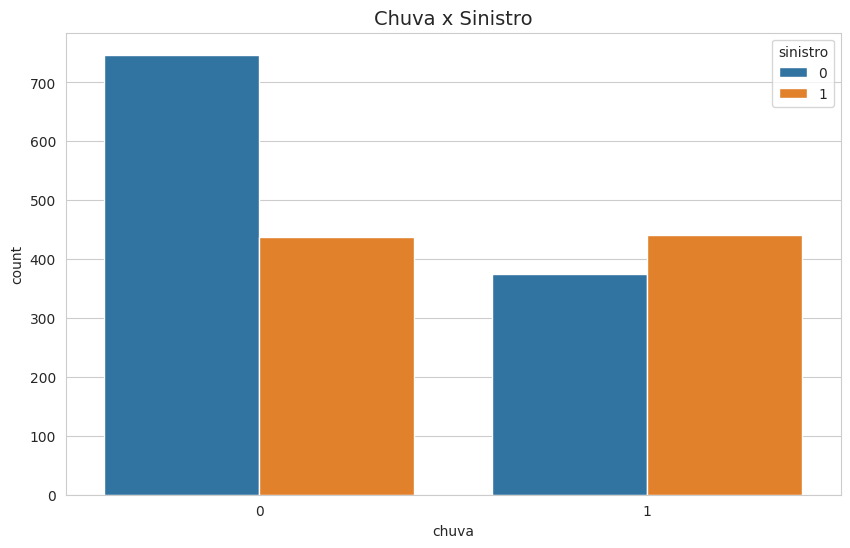

In [18]:
sns.countplot(
    x="chuva",
    hue="sinistro",
    data=data
)

plt.title("Chuva x Sinistro")

plt.show()

Condições climáticas adversas apresentam forte relação com aumento do risco operacional.

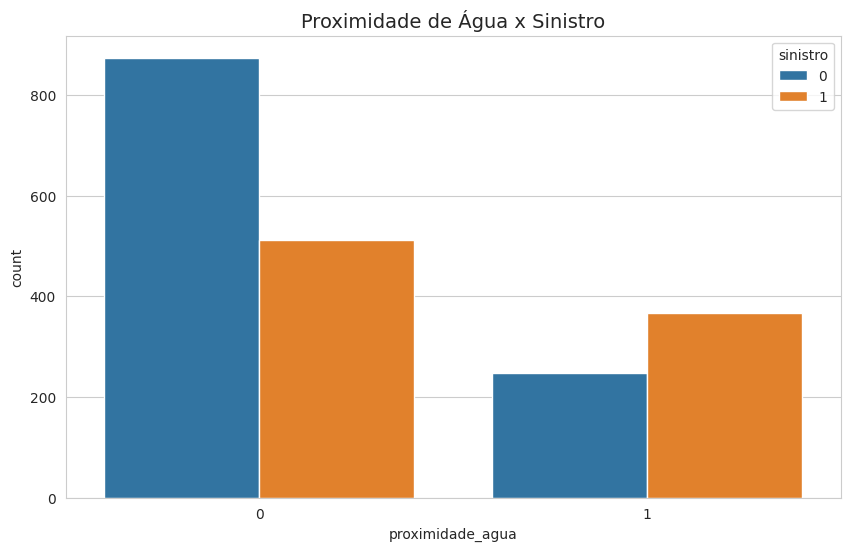

In [19]:
sns.countplot(
    x="proximidade_agua",
    hue="sinistro",
    data=data
)

plt.title("Proximidade de Água x Sinistro")

plt.show()

Operações próximas à água apresentaram maior incidência de sinistros.

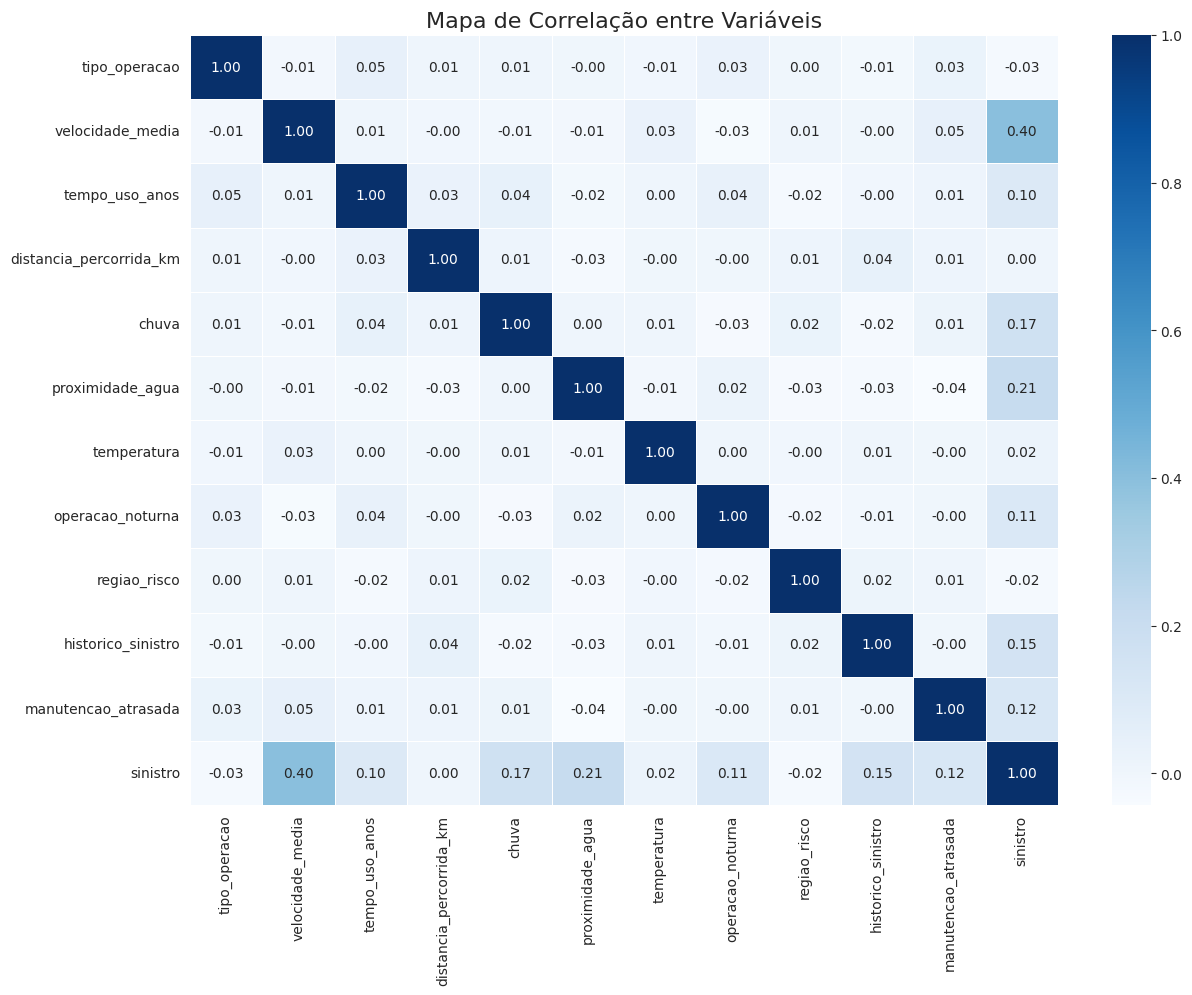

In [20]:
plt.figure(figsize=(14,10))

correlation = data.corr()

sns.heatmap(

    correlation,

    annot=True,

    fmt=".2f",

    cmap="Blues",

    linewidths=0.5

)

plt.title(
    "Mapa de Correlação entre Variáveis",
    fontsize=16
)

plt.show()

O mapa de correlação permite identificar relações entre as variáveis e o risco de sinistro.

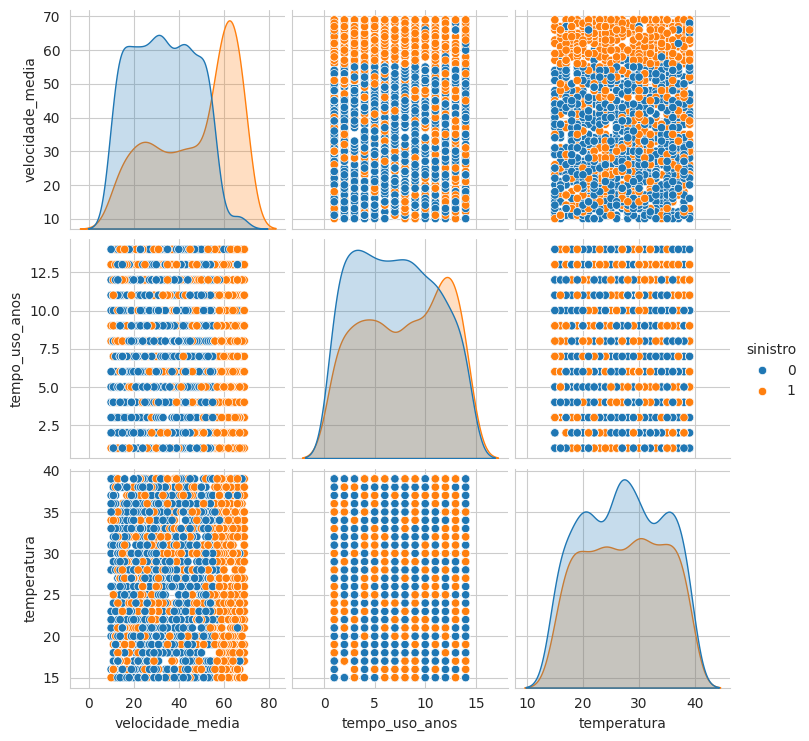

In [21]:
sns.pairplot(

    data[
        [
            "velocidade_media",
            "tempo_uso_anos",
            "temperatura",
            "sinistro"
        ]
    ],

    hue="sinistro"

)

plt.show()

O pairplot permite comparar distribuições e padrões entre as variáveis numéricas.

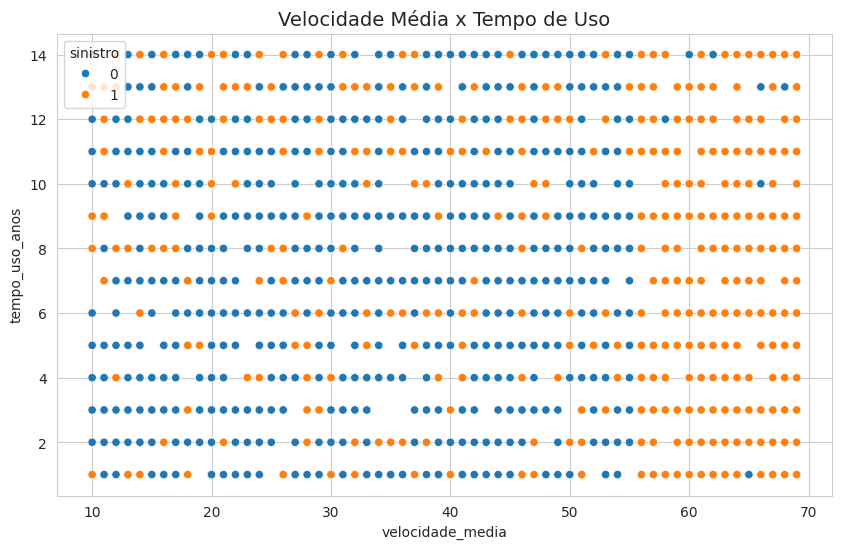

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    x="velocidade_media",
    y="tempo_uso_anos",
    hue="sinistro",
    data=data

)

plt.title(
    "Velocidade Média x Tempo de Uso"
)

plt.show()

Observa-se que equipamentos com maior velocidade média e maior tempo de uso apresentam maior concentração de sinistros.

# Insights Obtidos

A análise exploratória permitiu identificar padrões importantes relacionados ao risco de sinistro.

Principais insights:

- operações próximas à água aumentam o risco
- chuva influencia diretamente os sinistros
- velocidades elevadas aumentam a exposição ao risco
- manutenção atrasada apresenta relação com ocorrências
- histórico de sinistro influencia novos incidentes

Os resultados demonstram forte influência de fatores operacionais e ambientais na ocorrência de sinistros agrícolas.

In [23]:
data.to_csv(
    "dataset_sompo.csv",
    index=False
)

# Preparação para Modelagem

Nesta etapa os dados são separados entre variáveis independentes (features) e variável alvo (target), preparando o dataset para futuras etapas de Machine Learning.

In [24]:
X = data.drop("sinistro", axis=1)

y = data["sinistro"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   tipo_operacao  velocidade_media  tempo_uso_anos  distancia_percorrida_km  \
0              0                56              12                      101   
1              1                21               8                      905   
2              0                25               8                      202   
3              0                33               6                      798   
4              0                28              12                      360   

   chuva  proximidade_agua  temperatura  operacao_noturna  regiao_risco  \
0      1                 1           38                 0             1   
1      0                 0           26                 0             1   
2      0                 1           30                 0             2   
3      1                 0           26                 1             2   
4      0                 0           33                 0             1   

   historico_sinistro  manutencao_atrasada  
0                  

# Próximos Passos

Os dados preparados neste notebook servirão como base para futuras etapas do projeto:

- treinamento de modelos de Machine Learning
- geração de score de risco
- análise de importância das variáveis
- construção de dashboards
- desenvolvimento de APIs inteligentes

# Conclusão

A análise exploratória permitiu compreender fatores críticos relacionados ao risco de sinistro em equipamentos agrícolas.

Os resultados obtidos servirão como base para futuras etapas de modelagem preditiva utilizando Machine Learning.

A utilização de inteligência artificial possui grande potencial para auxiliar seguradoras na prevenção de perdas e tomada de decisão.

# Dataset Final Tratado

Abaixo está uma visualização do dataset após todas as etapas de preparação.

In [25]:
data.head()

,tipo_operacao,velocidade_media,tempo_uso_anos,distancia_percorrida_km,chuva,proximidade_agua,temperatura,operacao_noturna,regiao_risco,historico_sinistro,manutencao_atrasada,sinistro
0,0,56,12,101,1,1,38,0,1,0,0,1
1,1,21,8,905,0,0,26,0,1,0,1,0
2,0,25,8,202,0,1,30,0,2,0,0,0
3,0,33,6,798,1,0,26,1,2,0,0,0
4,0,28,12,360,0,0,33,0,1,0,0,0
